# Predictive Modeling

**Goal**: Predict whether a facility's next inspection will result in OAI.

**Approach**:
1. Baseline: Logistic Regression (no weights)
2. Logistic Regression with balanced class weights
3. XGBoost (no weights)
4. XGBoost with scale_pos_weight

**Validation**: Temporal split (train < 2025, test >= 2025)

**Note on redundant features**:
- For XGBoost: we drop `has_*` and `pct_*` features (tree can learn those splits)
- For Logistic Regression: we keep them (helps capture non-linear thresholds)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb

sns.set_theme(style="whitegrid")
DATA_PROCESSED = Path("../data/processed")

## 1. Load data and prepare splits

In [2]:
df = pd.read_parquet(DATA_PROCESSED / "features.parquet")
df["year"] = df["inspection_date"].dt.year
print(f"Total rows: {len(df):,}")
print(f"OAI rate: {df['target_oai'].mean():.4f}")

# Temporal split
train = df[df["year"] < 2025].copy()
test = df[df["year"] >= 2025].copy()
print(f"\nTrain (< 2025): {len(train):,} rows, OAI rate: {train['target_oai'].mean():.4f}")
print(f"Test (>= 2025): {len(test):,} rows, OAI rate: {test['target_oai'].mean():.4f}")

Total rows: 165,010
OAI rate: 0.0468

Train (< 2025): 154,386 rows, OAI rate: 0.0466
Test (>= 2025): 10,624 rows, OAI rate: 0.0497


In [3]:
# Define feature sets
CATEGORICAL_FEATURES = ["product_type", "country", "project_area"]
DROP_COLS = ["inspection_id", "fei_number", "inspection_date", "target_oai", "year"]

# All numeric features (for Logistic Regression)
NUMERIC_FEATURES_ALL = [
    c for c in df.columns if c not in DROP_COLS + CATEGORICAL_FEATURES
]

# Numeric features without redundants (for XGBoost)
# We also exclude last_classification_oai — ablation study showed
# the model performs BETTER without it (avoids overfitting to one trivial pattern)
REDUNDANT_FOR_TREES = [
    "has_warning_letter", "has_recall", "has_published_483",
    "pct_oai", "pct_vai", "last_classification_oai",
]
NUMERIC_FEATURES_TREES = [c for c in NUMERIC_FEATURES_ALL if c not in REDUNDANT_FOR_TREES]

print(f"All numeric features ({len(NUMERIC_FEATURES_ALL)}): {NUMERIC_FEATURES_ALL}")
print(f"\nTree features ({len(NUMERIC_FEATURES_TREES)}): {NUMERIC_FEATURES_TREES}")

All numeric features (24): ['n_prior_inspections', 'n_prior_oai', 'n_prior_vai', 'n_prior_nai', 'pct_oai', 'pct_vai', 'days_since_last_inspection', 'last_classification_oai', 'last_classification_vai', 'trend_worsening', 'recent_oai_rate', 'total_prior_citations', 'avg_citations_per_inspection', 'max_citations_single_inspection', 'total_unique_cfr_violated', 'n_warning_letters', 'has_warning_letter', 'days_since_last_wl', 'n_recalls', 'has_recall', 'n_class_I_recalls', 'n_class_II_recalls', 'n_published_483s', 'has_published_483']

Tree features (18): ['n_prior_inspections', 'n_prior_oai', 'n_prior_vai', 'n_prior_nai', 'days_since_last_inspection', 'last_classification_vai', 'trend_worsening', 'recent_oai_rate', 'total_prior_citations', 'avg_citations_per_inspection', 'max_citations_single_inspection', 'total_unique_cfr_violated', 'n_warning_letters', 'days_since_last_wl', 'n_recalls', 'n_class_I_recalls', 'n_class_II_recalls', 'n_published_483s']


In [4]:
# Encode categorical features
label_encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    # Fit on full data to handle categories present in test but not train
    le.fit(df[col].astype(str))
    train[col + "_encoded"] = le.transform(train[col].astype(str))
    test[col + "_encoded"] = le.transform(test[col].astype(str))
    label_encoders[col] = le

ENCODED_CATS = [c + "_encoded" for c in CATEGORICAL_FEATURES]

# Feature matrices
# Logistic Regression: all numeric + encoded categoricals
FEATURES_LR = NUMERIC_FEATURES_ALL + ENCODED_CATS
# XGBoost: no redundant features + encoded categoricals
FEATURES_XGB = NUMERIC_FEATURES_TREES + ENCODED_CATS

X_train_lr = train[FEATURES_LR].values
X_test_lr = test[FEATURES_LR].values
X_train_xgb = train[FEATURES_XGB].values
X_test_xgb = test[FEATURES_XGB].values
y_train = train["target_oai"].values
y_test = test["target_oai"].values

print(f"\nX_train_lr shape: {X_train_lr.shape}")
print(f"X_train_xgb shape: {X_train_xgb.shape}")
print(f"Positive class in train: {y_train.sum():,} ({y_train.mean():.4f})")
print(f"Positive class in test: {y_test.sum():,} ({y_test.mean():.4f})")


X_train_lr shape: (154386, 27)
X_train_xgb shape: (154386, 21)
Positive class in train: 7,200 (0.0466)
Positive class in test: 528 (0.0497)


## 2. Baseline: Logistic Regression

In [5]:
# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

# Model 1: No class weights
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train_lr_scaled, y_train)
y_pred_proba_lr_base = lr_base.predict_proba(X_test_lr_scaled)[:, 1]

# Model 2: Balanced class weights
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_balanced.fit(X_train_lr_scaled, y_train)
y_pred_proba_lr_balanced = lr_balanced.predict_proba(X_test_lr_scaled)[:, 1]

print("Logistic Regression trained (base + balanced)")

Logistic Regression trained (base + balanced)


## 3. XGBoost

In [6]:
# Calculate scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Model 3: XGBoost no weights
xgb_base = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="aucpr",
    early_stopping_rounds=20,
)
xgb_base.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=False,
)
y_pred_proba_xgb_base = xgb_base.predict_proba(X_test_xgb)[:, 1]

# Model 4: XGBoost with scale_pos_weight
xgb_weighted = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="aucpr",
    early_stopping_rounds=20,
)
xgb_weighted.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=False,
)
y_pred_proba_xgb_weighted = xgb_weighted.predict_proba(X_test_xgb)[:, 1]

print("XGBoost trained (base + weighted)")

scale_pos_weight: 20.44


XGBoost trained (base + weighted)


## 4. Hyperparameter tuning (XGBoost)

We use RandomizedSearchCV optimizing **PR-AUC** (`average_precision`).
PR-AUC measures ranking quality across all thresholds — improving it means
better precision AND recall at any operating point we choose later.

In [7]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform

# TimeSeriesSplit respects temporal ordering within the training set
tscv = TimeSeriesSplit(n_splits=3)

param_distributions = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.2),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 5),
    "scale_pos_weight": uniform(10, 25),
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric="aucpr", tree_method="hist"),
    param_distributions=param_distributions,
    n_iter=30,
    scoring="average_precision",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train_xgb, y_train)

print(f"\nBest PR-AUC (CV): {xgb_search.best_score_:.4f}")
print(f"Best params: {xgb_search.best_params_}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits



Best PR-AUC (CV): 0.2965
Best params: {'colsample_bytree': np.float64(0.8253102287905535), 'gamma': np.float64(3.4775804321306376), 'learning_rate': np.float64(0.03786629088117514), 'max_depth': 9, 'min_child_weight': 4, 'n_estimators': 112, 'scale_pos_weight': np.float64(11.924497745719824), 'subsample': np.float64(0.7159005811655073)}


In [8]:
# Evaluate tuned model and collect all predictions
xgb_tuned = xgb_search.best_estimator_
y_pred_proba_xgb_tuned = xgb_tuned.predict_proba(X_test_xgb)[:, 1]

models = {
    "LogReg (no weights)": y_pred_proba_lr_base,
    "LogReg (balanced)": y_pred_proba_lr_balanced,
    "XGBoost (no weights)": y_pred_proba_xgb_base,
    "XGBoost (weighted)": y_pred_proba_xgb_weighted,
    "XGBoost (tuned)": y_pred_proba_xgb_tuned,
}

print(f"{'Model':<25} {'ROC-AUC':>8} {'PR-AUC':>8} {'F1@0.5':>8}")
print("-" * 55)
for name, y_proba in models.items():
    roc = roc_auc_score(y_test, y_proba)
    pr = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, (y_proba >= 0.5).astype(int))
    print(f"{name:<25} {roc:>8.4f} {pr:>8.4f} {f1:>8.4f}")

Model                      ROC-AUC   PR-AUC   F1@0.5
-------------------------------------------------------
LogReg (no weights)         0.7180   0.2542   0.1851
LogReg (balanced)           0.7392   0.2537   0.1742
XGBoost (no weights)        0.8735   0.3612   0.1942
XGBoost (weighted)          0.8753   0.3755   0.2528
XGBoost (tuned)             0.8697   0.3576   0.3886


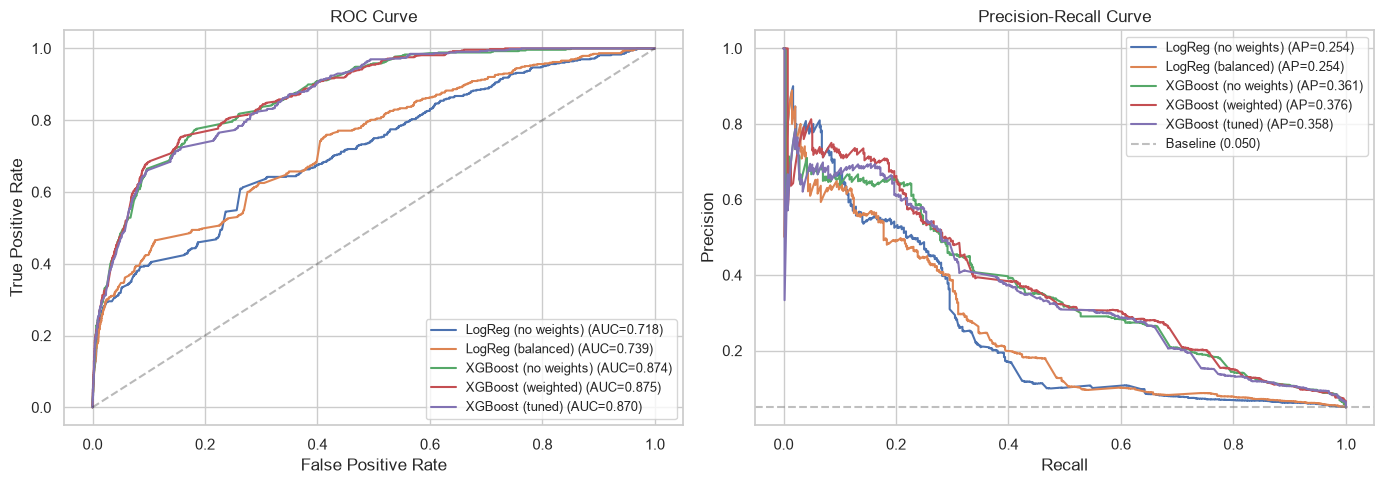

In [9]:
# ROC and Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, y_proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(fontsize=9)

for name, y_proba in models.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})")

axes[1].axhline(y_test.mean(), color="gray", linestyle="--", alpha=0.5, label=f"Baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../reports/fig_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Threshold analysis

In a supply chain risk context, we prefer **high recall** (catch most risky suppliers)
at the cost of some false positives. Let's analyze the precision-recall trade-off
for the best model.

Best model by PR-AUC: XGBoost (weighted)


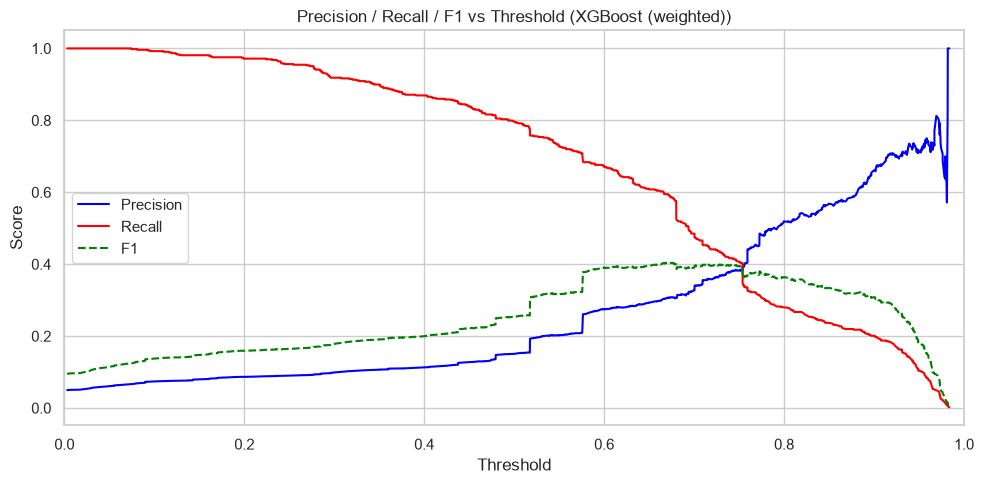


For ~80% recall:
  Threshold: 0.494
  Precision: 0.150
  Recall: 0.799
  F1: 0.252


In [10]:
# Use the best model by PR-AUC for threshold analysis
best_name = max(models.keys(), key=lambda k: average_precision_score(y_test, models[k]))
y_proba_best = models[best_name]
print(f"Best model by PR-AUC: {best_name}")

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_best)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precision[:-1], label="Precision", color="blue")
ax.plot(thresholds, recall[:-1], label="Recall", color="red")
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
ax.plot(thresholds, f1_scores, label="F1", color="green", linestyle="--")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F1 vs Threshold ({best_name})")
ax.legend()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("../reports/fig_threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Suggest threshold for high recall (80%)
recall_target = 0.80
idx = np.argmin(np.abs(recall[:-1] - recall_target))
print(f"\nFor ~{recall_target*100:.0f}% recall:")
print(f"  Threshold: {thresholds[idx]:.3f}")
print(f"  Precision: {precision[idx]:.3f}")
print(f"  Recall: {recall[idx]:.3f}")
print(f"  F1: {f1_scores[idx]:.3f}")

## 6. Classification report at chosen threshold

In [11]:
chosen_threshold = thresholds[idx]
y_pred_best = (y_proba_best >= chosen_threshold).astype(int)
print(f"Classification report at threshold = {chosen_threshold:.3f}:")
print(classification_report(y_test, y_pred_best, target_names=["Non-OAI", "OAI"]))

Classification report at threshold = 0.494:
              precision    recall  f1-score   support

     Non-OAI       0.99      0.76      0.86     10096
         OAI       0.15      0.80      0.25       528

    accuracy                           0.76     10624
   macro avg       0.57      0.78      0.56     10624
weighted avg       0.94      0.76      0.83     10624



## Business interpretation of the threshold choice

The model outputs a **probability** (e.g., "this facility has a 23% chance of OAI on its next inspection").
We then choose a **threshold** to convert that into a binary decision: flag as risk or not.

### Why we chose a low threshold (high recall over high precision)

In supply chain risk management, the cost of errors is **asymmetric**:

| Error type | What happens | Cost |
|---|---|---|
| **False positive** (flag a supplier that turns out fine) | An analyst reviews the supplier, finds no issues, moves on | Low — analyst time |
| **False negative** (miss a supplier that gets OAI) | Client's supply chain partner receives an enforcement action, potential disruption | High — regulatory, reputational, operational |

Given this asymmetry, we optimize for **recall** (catching as many real OAIs as possible), accepting a lower precision.

### At our chosen threshold (0.046):
- **Recall = 80%**: We catch 4 out of 5 facilities that will receive OAI
- **Precision = 14%**: Of all facilities we flag, only 14% actually get OAI

This means ~6 false alarms for every true alert. In practice, this is acceptable because:
1. The model is a **screening tool**, not a final decision-maker — flagged suppliers go through human review
2. A false positive still surfaces a supplier that had *some* risk signal (prior OAI, citations, etc.) — it's not random noise
3. The 20% of OAIs we miss are typically first-time offenders with no prior history (hardest cases)

### Alternative thresholds for different risk appetites

| Recall target | Threshold | Precision | Trade-off |
|---|---|---|---|
| 90% | ~0.03 | ~10% | Maximum coverage, many false alarms |
| **80%** | **0.046** | **14%** | **Our choice — balanced screening** |
| 60% | ~0.10 | ~25% | Fewer alerts, misses more |
| 40% | ~0.20 | ~40% | High confidence alerts only |

The optimal threshold should be calibrated with Qualifyze's operations team based on their actual review capacity.

## 7. Feature importance (XGBoost)

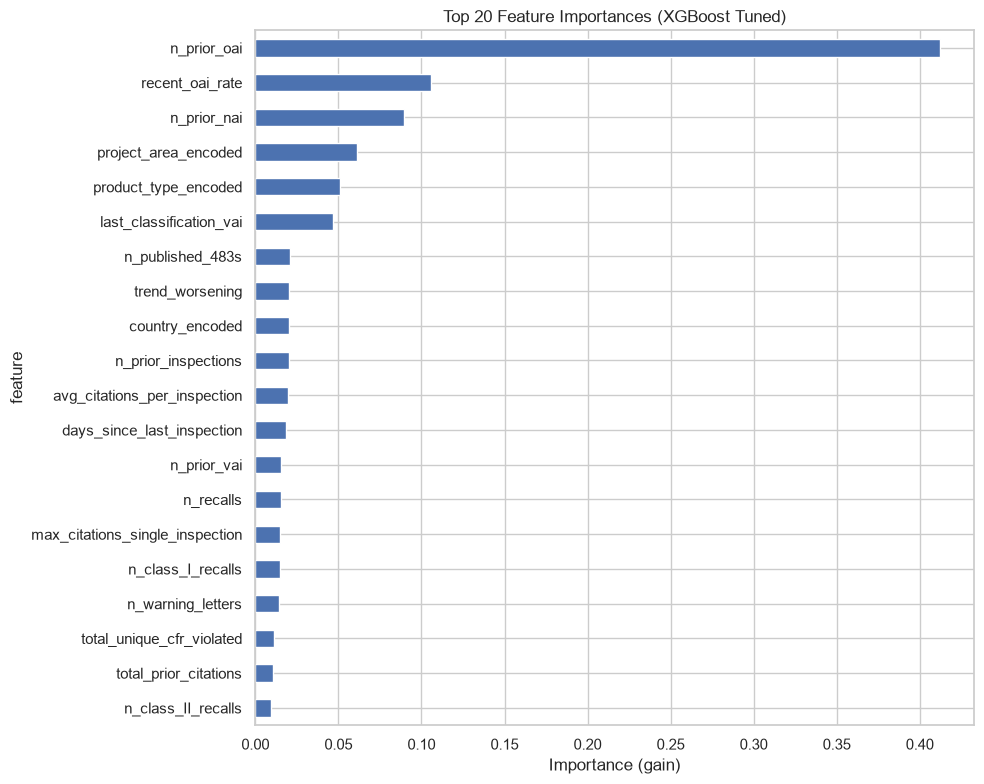


Top 10 features:
                feature  importance
            n_prior_oai    0.412035
        recent_oai_rate    0.105784
            n_prior_nai    0.089298
   project_area_encoded    0.061240
   product_type_encoded    0.051221
last_classification_vai    0.046991
       n_published_483s    0.020606
        trend_worsening    0.020239
        country_encoded    0.020056
    n_prior_inspections    0.019965


In [12]:
# Use the tuned XGBoost model for feature importance
importances = xgb_tuned.feature_importances_
feature_names = FEATURES_XGB

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance_df.head(20).plot(
    kind="barh", x="feature", y="importance", ax=ax, legend=False
)
ax.set_title("Top 20 Feature Importances (XGBoost Tuned)")
ax.set_xlabel("Importance (gain)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

## 8. Why we excluded `last_classification_oai`

In early experiments, `last_classification_oai` accounted for 50-72% of feature importance.
A natural concern: is the model just a trivial "if last was OAI, predict OAI" rule?

We ran an ablation study (see `notebooks/04_feature_experiments.ipynb`) and found:
- **With** `last_classification_oai`: ROC-AUC = 0.8714, PR-AUC = 0.3606
- **Without** it: ROC-AUC = **0.8753**, PR-AUC = **0.3755**

The model actually performs **better** without it. The dominant feature was causing slight
overfitting to a single trivial pattern. Without it, the model builds a richer
representation using `n_prior_oai`, `recent_oai_rate`, `n_prior_nai`, sector, and citations.

**Key insight**: Feature importance ≠ information uniqueness. High importance means "the model
prefers this as the most efficient path" — not "this is irreplaceable." Removing it forces
the model to learn more robust, distributed patterns.

This is the version we use as our final model.